Netflix Content Analysis: Trends in Genres, Countries, and Growth
=

By Hussein (Nizar) Tamimme

LinkedIn: https://www.linkedin.com/in/hussein-tamimme-1943072a5?utm_source=share_via&utm_content=profile&utm_medium

**1. Introduction**
=

This project analyzes Netflix's catalog to understand content trends, production countries, genres, and audience targeting. The goal is to uncover how Netflix's content strategy evolved over time.

In [1]:
# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

**2. Dataset Overview**
=
"About this Dataset: Netflix is one of the most popular media and video streaming platforms. They have over 8000 movies or tv shows available on their platform, as of mid-2021, they have over 200M Subscribers globally. This tabular dataset consists of listings of all the movies and tv shows available on Netflix, along with details such as - cast, directors, ratings, release year, duration, etc." [Kaggle, Shivam Bansal]


**Columns**
1. ***date_added:*** The date when the title was added to the Netflix platform.
2. ***release_year:*** The year the movie or TV show was originally released.
3. ***rating:*** The content maturity rating (e.g., TV-MA, PG, PG-13), indicating the appropriate audience age group.
4. ***duration:*** The length of the content. For movies it is in minutes, and for TV shows it is in number of seasons.
5. ***listed_in:*** The genre or category of the title (e.g., Drama, Comedy, Documentaries). Some titles belong to multiple genres.
6. ***title:*** The name of the movie or TV show available on Netflix.
7. ***type:*** Indicates whether the title is a Movie or a TV Show. Useful for analyzing trends separately for movies vs TV content.
8. ***country:*** The country where the content was produced.

For this work analysis I dropped the show_id, description, cast, and director columns and the main focus will be on the 8 columns that were previously mentioned

In [2]:
df = pd.read_csv("../data/netflix_titles.csv")
df = df.drop(columns=['show_id', 'description','cast','director'])
print(df.shape)
df.head()

(8807, 8)


,type,title,country,date_added,release_year,rating,duration,listed_in
0,Movie,Dick Johnson Is Dead,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries
1,TV Show,Blood & Water,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,Ganglands,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,Jailbirds New Orleans,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,TV Show,Kota Factory,India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


In [3]:
df.info()
df.isnull().sum()
def extract_duration(val):
    if pd.isna(val):
        return np.nan
    val = str(val)
    if "Season" in val:
        return int(val.split()[0])  # number of seasons
    elif "min" in val:
        return int(val.split()[0])  # duration in minutes
    else:
        return np.nan


df['duration_num'] = df['duration'].apply(extract_duration)
print("Number of duplicated rows: ",df.duplicated().sum())

invalid_duration = df[df['duration_num'] <= 0]
print("Number of invalid durations:", len(invalid_duration))

print("Min year:", df['release_year'].min())
print("Max year:", df['release_year'].max())

unusual_years = df[(df['release_year'] < 1900) | (df['release_year'] > 2026)]
print("Unusual years: ",len(unusual_years[['title', 'release_year']]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8807 non-null   object
 1   title         8807 non-null   object
 2   country       7976 non-null   object
 3   date_added    8797 non-null   object
 4   release_year  8807 non-null   int64 
 5   rating        8803 non-null   object
 6   duration      8804 non-null   object
 7   listed_in     8807 non-null   object
dtypes: int64(1), object(7)
memory usage: 550.6+ KB
Number of duplicated rows:  0
Number of invalid durations: 0
Min year: 1925
Max year: 2021
Unusual years:  0


**3. Data Cleaning**
=
**Handling Missing values:**
Some Columns had missing values. date_added for example had only 10 missing values, Which is a very small number so my strategy was to drop the rows with the missing values.
The same goes for the duration, and rating columns they had a really small number of missing values so dropping these rows was a good strategy.

The main problem was the country column, it is an essential column for my analysis. The problem is that the missing values are about 10% of the dataset so dropping them or dropping the column was not a choice. So I preserved it, but I imputed the keyword "Unkown" to ensure unbiased analysis and keeping the countr column

**Correcting date_added:**
The column date_added data type was string and for better analysis and extracting more insights
I trimmed the white spaces to ensure safe conversion then converted the data type to date time.
Lastly I extracted the year from all dates and created a new column called "year_added" for deeper insights

our data is now ready. No duplicated values, no outliers, and the missing values are gone

In [4]:
df = df.dropna(subset=['date_added', 'duration', 'rating'])
df['country'] = df['country'].fillna("Unknown")

df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year

In [5]:
print(df.isnull().sum())
df.describe()

type            0
title           0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
duration_num    0
year_added      0
dtype: int64


,date_added,release_year,duration_num,year_added
count,8790,8790.000000,8790.000000,8790.000000
mean,2019-05-17 21:44:01.638225408,2014.183163,69.934471,2018.873606
min,2008-01-01 00:00:00,1925.000000,1.000000,2008.000000
25%,2018-04-06 00:00:00,2013.000000,2.000000,2018.000000
50%,2019-07-03 00:00:00,2017.000000,88.500000,2019.000000
75%,2020-08-19 18:00:00,2019.000000,106.000000,2020.000000
max,2021-09-25 00:00:00,2021.000000,312.000000,2021.000000
std,NaN,8.825466,50.794433,1.573568


In [6]:
df.to_csv("../data/processed_data.csv", index=False)

**Important Variables (For Later use)**

In [7]:
titles_per_year = df.groupby('year_added').size()
num_titles = titles_per_year.values 
top10_values = df['listed_in'].value_counts().head(10)
titles_per_country = df['country'].value_counts().head(10) 
ratings_count = df['rating'].value_counts()
genre_country_ct = pd.crosstab(df['country'], df['listed_in'])
years = titles_per_year.index
top_countries = genre_country_ct.sum(axis=1).sort_values(ascending=False).head(5).index
top_genres = genre_country_ct.sum(axis=0).sort_values(ascending=False).head(5).index
top_ct_data = genre_country_ct.loc[top_countries, top_genres]

**Visual's colors**

In [8]:
cmap = mcolors.LinearSegmentedColormap.from_list("", ["#FFC1B6", "#E50914"])
norm_line = mcolors.Normalize(vmin=num_titles.min(), vmax=num_titles.max())
norm_bar = mcolors.Normalize(vmin=top10_values.min(), vmax=top10_values.max())

**4. Key Questions**
=

**1st: What are the most common genres on Netflix?**
-

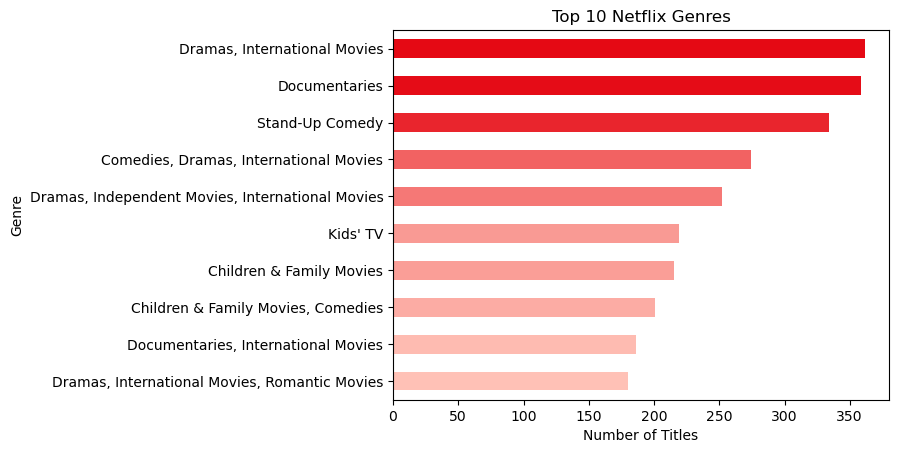

In [9]:
colors_bar = [cmap(norm_bar(value)) for value in top10_values]

top10_values.plot(kind='barh', color=colors_bar)
plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.gca().invert_yaxis()
plt.show()

**Dramas** dominate Netflix’s catalog, followed by documentaries and comedies. This suggests Netflix prioritizes storytelling-focused content that appeals to a broad audience.




**2nd: Which countries produce the most content?**
-

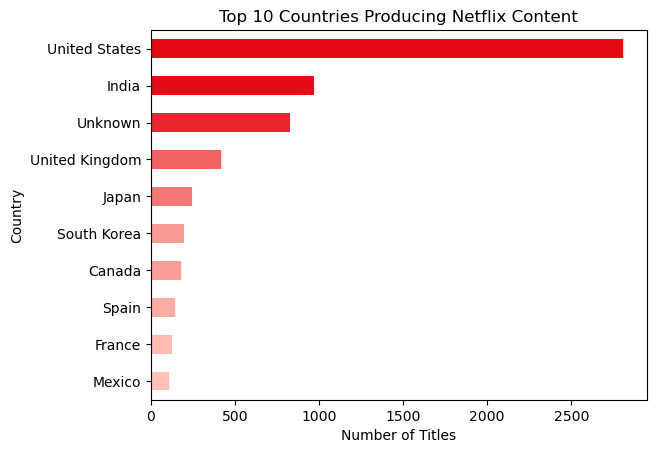

In [10]:
titles_per_country.plot(kind='barh', color=colors_bar)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

The countries producing the most Netflix content are led by the **United States**, which dominates due to Hollywood’s large output and Netflix’s home market focus. India and South Korea are rapidly growing, reflecting Netflix’s push into regional and local-language content to attract wider audiences. The United Kingdom, Canada, and several European countries like France and Spain contribute high-quality series and films, often in smaller volumes. Overall, Netflix’s content strategy shows a clear trend toward global diversification, balancing US dominance with investments in emerging markets to appeal to regional tastes.




**3rd: How has Netflix's catalog grown over time?**
-

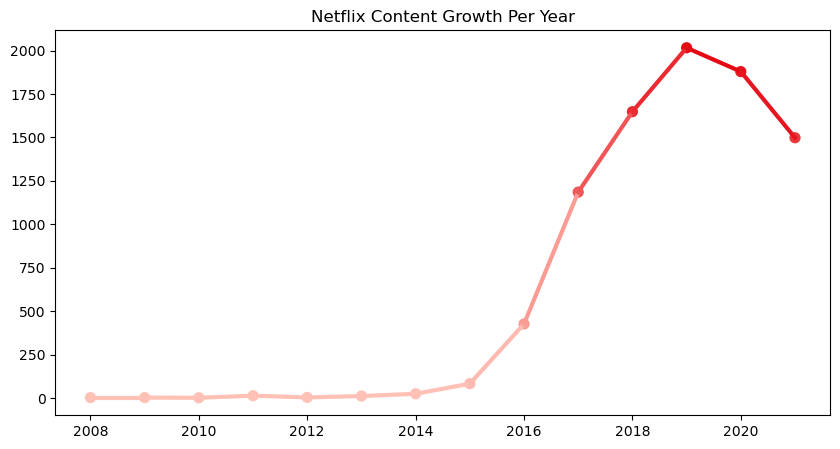

In [11]:
colors_line = [cmap(norm_line(v)) for v in num_titles[:-1]]

fig, ax = plt.subplots(figsize=(10,5))
for i in range(len(years)-1):
    ax.plot(years[i:i+2], num_titles[i:i+2], color=colors_line[i], linewidth=3)

ax.scatter(years, num_titles, color=[cmap(norm_line(v)) for v in num_titles], s=50)
ax.set_title("Netflix Content Growth Per Year")
plt.show()

After early streaming growth, Netflix’s total title count dipped as licensed content declined, then rebounded due to heavy investment in original series and films. **Today the service has more content than in much of the 2010s, with original productions making up an increasingly large share of its catalog.**



**4th: How do Genres vary by Country?**
-

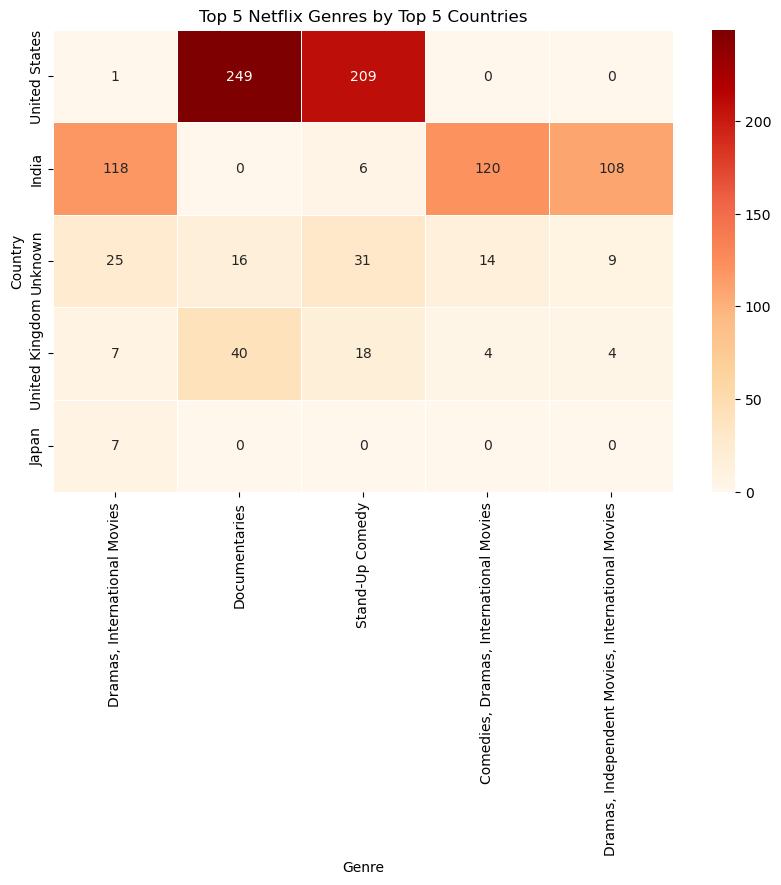

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(top_ct_data, annot=True, fmt='d', cmap="OrRd", linewidths=.5)
plt.title("Top 5 Netflix Genres by Top 5 Countries")
plt.xlabel("Genre")
plt.ylabel("Country")
plt.show()

As shown, there are regional differences in Netflix content trends: **the United States strongly dominates documentaries and stand-up comedy**, while India stands out as **the most diverse**, leading in multiple international and hybrid drama genres. The United Kingdom has a **smaller but notable focus on documentaries**, and **Japan has very limited representation overall**. The “Unknown” category reflects missing or unspecified country data and shows a low but fairly even spread across genres. Overall, the U.S. specializes in niche formats, whereas India drives broader, internationally blended content.



**5th: Are movies or TV shows growing faster?**
-

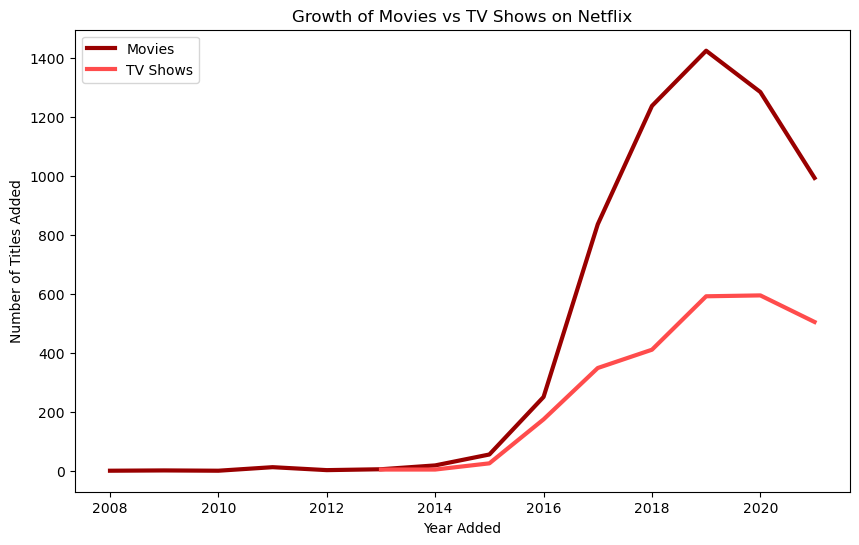

In [13]:
growth = df.groupby(['year_added', 'type']).size().unstack()
plt.figure(figsize=(10,6))

plt.plot(growth.index, growth['Movie'], label='Movies', color='#990000', linewidth=3)
plt.plot(growth.index, growth['TV Show'], label='TV Shows', color='#FF4C4C', linewidth=3)

plt.title("Growth of Movies vs TV Shows on Netflix")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")
plt.legend()
plt.show()

In the beginning both were growing equally until 2016 then **the movies had a huge jump** while the TV shows remained growing slowly 



**6th: Which countries are expanding production the fastest, and How is the Content in general growing by Country?**
-

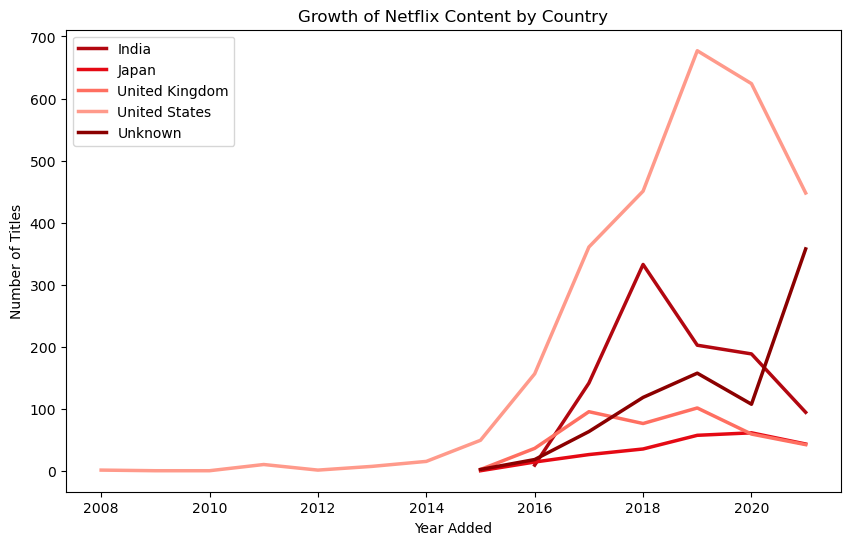

In [14]:
country_growth = (
    df[df['country'].isin(top_countries)]
    .groupby(['year_added', 'country'])
    .size()
    .unstack()
)
CountryColors = ['#B20710', '#E50914', '#FF6F61', '#FF9A8B', '#8B0000']

plt.figure(figsize=(10,6))

for i, country in enumerate(country_growth.columns):
    plt.plot(country_growth.index,
             country_growth[country],
             label=country,
             color=CountryColors[i],
             linewidth=2.5)

plt.title("Growth of Netflix Content by Country")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend()
plt.show()

In 2008, the US was the sole producer of content, experiencing slow but steady growth. By 2015, US content production began accelerating rapidly, while other countries such as India, Japan, and the UK entered the scene, though none matched the US's level of success. Interestingly, some lesser-known countries started with modest growth but began increasing steadily, showing promising potential for the future.



**7th: How has Netflix's genres grown over time?**
-

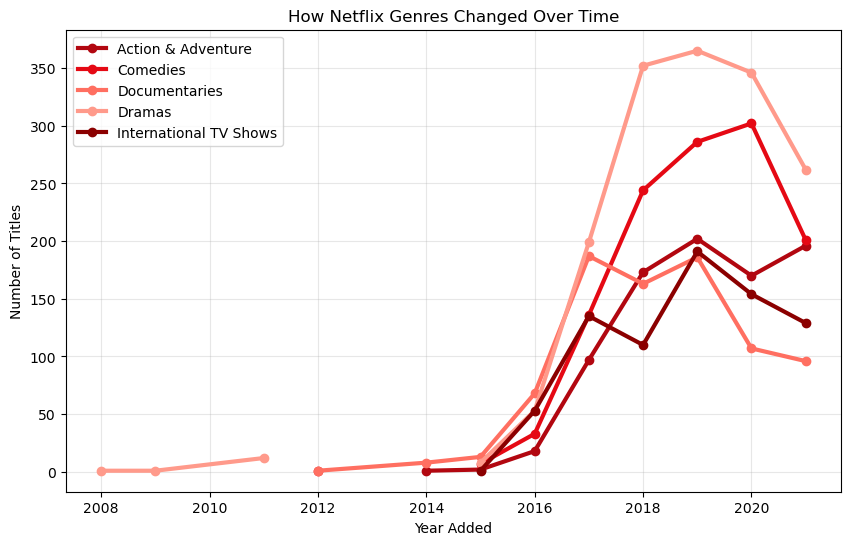

In [15]:
df['main_genre'] = df['listed_in'].str.split(',').str[0]
top_genres = df['main_genre'].value_counts().head(5).index
genre_growth = (
    df[df['main_genre'].isin(top_genres)]
    .groupby(['year_added','main_genre'])
    .size()
    .unstack()
)
GGcolors = ['#B20710', '#E50914', '#FF6F61', '#FF9A8B', '#8B0000']

plt.figure(figsize=(10,6))

for i, genre in enumerate(genre_growth.columns):
    plt.plot(
        genre_growth.index,
        genre_growth[genre],
        label=genre,
        color=GGcolors[i],
        linewidth=3,
        marker='o'
    )

plt.title("How Netflix Genres Changed Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Genre's distribution remained relatively limited until around 2015–2016, after which all genres experienced a sharp and rapid increase, marking a major expansion phase. Among them, dramas emerged as the dominant genre, reaching the highest levels of growth, followed by comedies, which also showed strong and consistent increases. Documentaries saw a noticeable rise during the expansion period but declined after 2019, suggesting a possible shift in focus or audience interest. Meanwhile, international TV shows grew steadily, reflecting Netflix’s increasing investment in global content. Overall, most genres peaked between 2018 and 2020 before slightly declining, indicating a period of saturation or strategic adjustment in content production.


**8th: What audience ratings dominate Netflix?**
-

C:\Users\Hussein\AppData\Local\Temp\ipykernel_17096\1297992772.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='rating', order=order, palette=GGcolors)
C:\Users\Hussein\AppData\Local\Temp\ipykernel_17096\1297992772.py:3: UserWarning: 
The palette list has fewer values (5) than needed (14) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df, y='rating', order=order, palette=GGcolors)


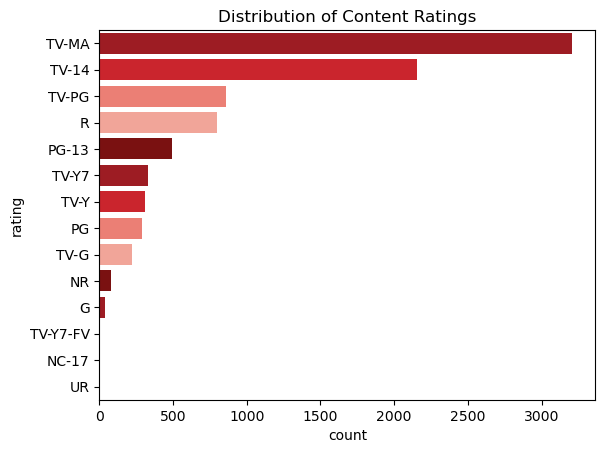

In [16]:
order = df['rating'].value_counts().index

sns.countplot(data=df, y='rating', order=order, palette=GGcolors)

plt.title("Distribution of Content Ratings")
plt.show()

Content ratings on Netflix shows a clear dominance of mature and teen-focused content. TV-MA holds the highest count by a significant margin, indicating that Netflix primarily targets adult audiences. This is followed by TV-14, which also represents a large portion of the catalog, reinforcing the platform’s focus on older viewers. In contrast, family-friendly ratings such as TV-G, G, and TV-Y appear much less frequently, suggesting limited content for younger audiences. Mid-range ratings like PG-13, TV-PG, and R have moderate representation, providing some balance, but they are still overshadowed by more mature categories. Overall, the data highlights Netflix’s strategic emphasis on producing and distributing content geared toward mature and teenage audiences rather than children.

**5. Key Insights**
=

**Genre Dominance:**
Dramas are the most prevalent genre on Netflix, followed by documentaries and comedies, highlighting a strong focus on storytelling-driven content that appeals to wide audiences.

**Global Content Strategy:**
The United States remains the leading content producer, but countries like India and South Korea are rapidly growing. This reflects Netflix’s strategic shift toward global diversification and investment in regional content.

**Catalog Evolution:**
After a decline due to reduced licensed content, Netflix’s catalog rebounded through heavy investment in original productions, which now form a significant portion of its library.

**Regional Content Differences:**
The U.S. specializes in documentaries and stand-up comedy, while India leads in diverse and internationally blended genres. Other countries contribute more niche or smaller-scale content.

**Movies vs TV Shows Growth:**
Both grew steadily until around 2016, after which movies experienced a sharp increase, while TV shows continued growing at a slower, more consistent pace.

**Expansion Timeline:**
Netflix content growth accelerated significantly after 2015, expanding beyond the U.S. into global markets, with emerging countries showing strong future potential.

**Genre Trends Over Time:**
Most genres saw rapid growth between 2016 and 2020, peaking during this period before slightly declining, suggesting market saturation or strategic shifts. Dramas and comedies led this growth, while documentaries declined after 2019.

**Audience Targeting:**
Netflix primarily targets mature and teen audiences, with TV-MA and TV-14 dominating the platform, while children’s content remains relatively limited.





What to do next?
=

**Expand Investment in International Content:** Netflix should continue increasing investment in high-growth markets like India and South Korea. These regions show strong momentum and help attract local audiences while also appealing globally (e.g., global success of non-English content).

**Maintain Leadership in Dramas:** Since dramas dominate the platform, Netflix should continue producing them but focus on:

1. Unique storytelling formats
2. Cross-genre combinations (drama + thriller, drama + sci-fi)
3. This helps avoid saturation and keeps audiences engaged.

**Increase Family & Kids Content:** The platform currently underrepresents child-friendly content. Expanding in this area can:

1. Broaden audience reach
2. Increase subscriptions from families
3. Improve long-term customer retention

**Balance Movies and TV Shows Strategy:** Movies have shown rapid growth after 2016, but TV shows are key for long-term engagement. Netflix should:

1. Use movies for quick audienc attraction
2. Use TV shows to maintain retention and binge-watching

**Diversify Genre Portfolio:** While dramas, comedies, and documentaries dominate, Netflix should:

1. Invest in underrepresented genres (e.g., sci-fi, niche categories)
2. Experiment with emerging trends
3. This reduces risk and captures new audience segments.

**Continue Focus on Mature & Teen Audiences but Add Balance:** Netflix’s catalog heavily targets TV-MA and TV-14 audiences. While this is effective, adding more balanced ratings can:

1. Attract wider demographics
2. Improve brand inclusivity

**Adapt to Market Saturation:** Since content peaked around 2018–2020, Netflix should:

1. Focus on quality over quantity
2. Prioritize high-impact productions
3. Reduce oversaturation in dominant genres

**Netflix’s future success depends on balancing global expansion, content diversity, and data-driven decision-making while maintaining its core strengths in storytelling and audience engagement.**

C:\Users\Hussein\AppData\Local\Temp\ipykernel_17096\1100976932.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


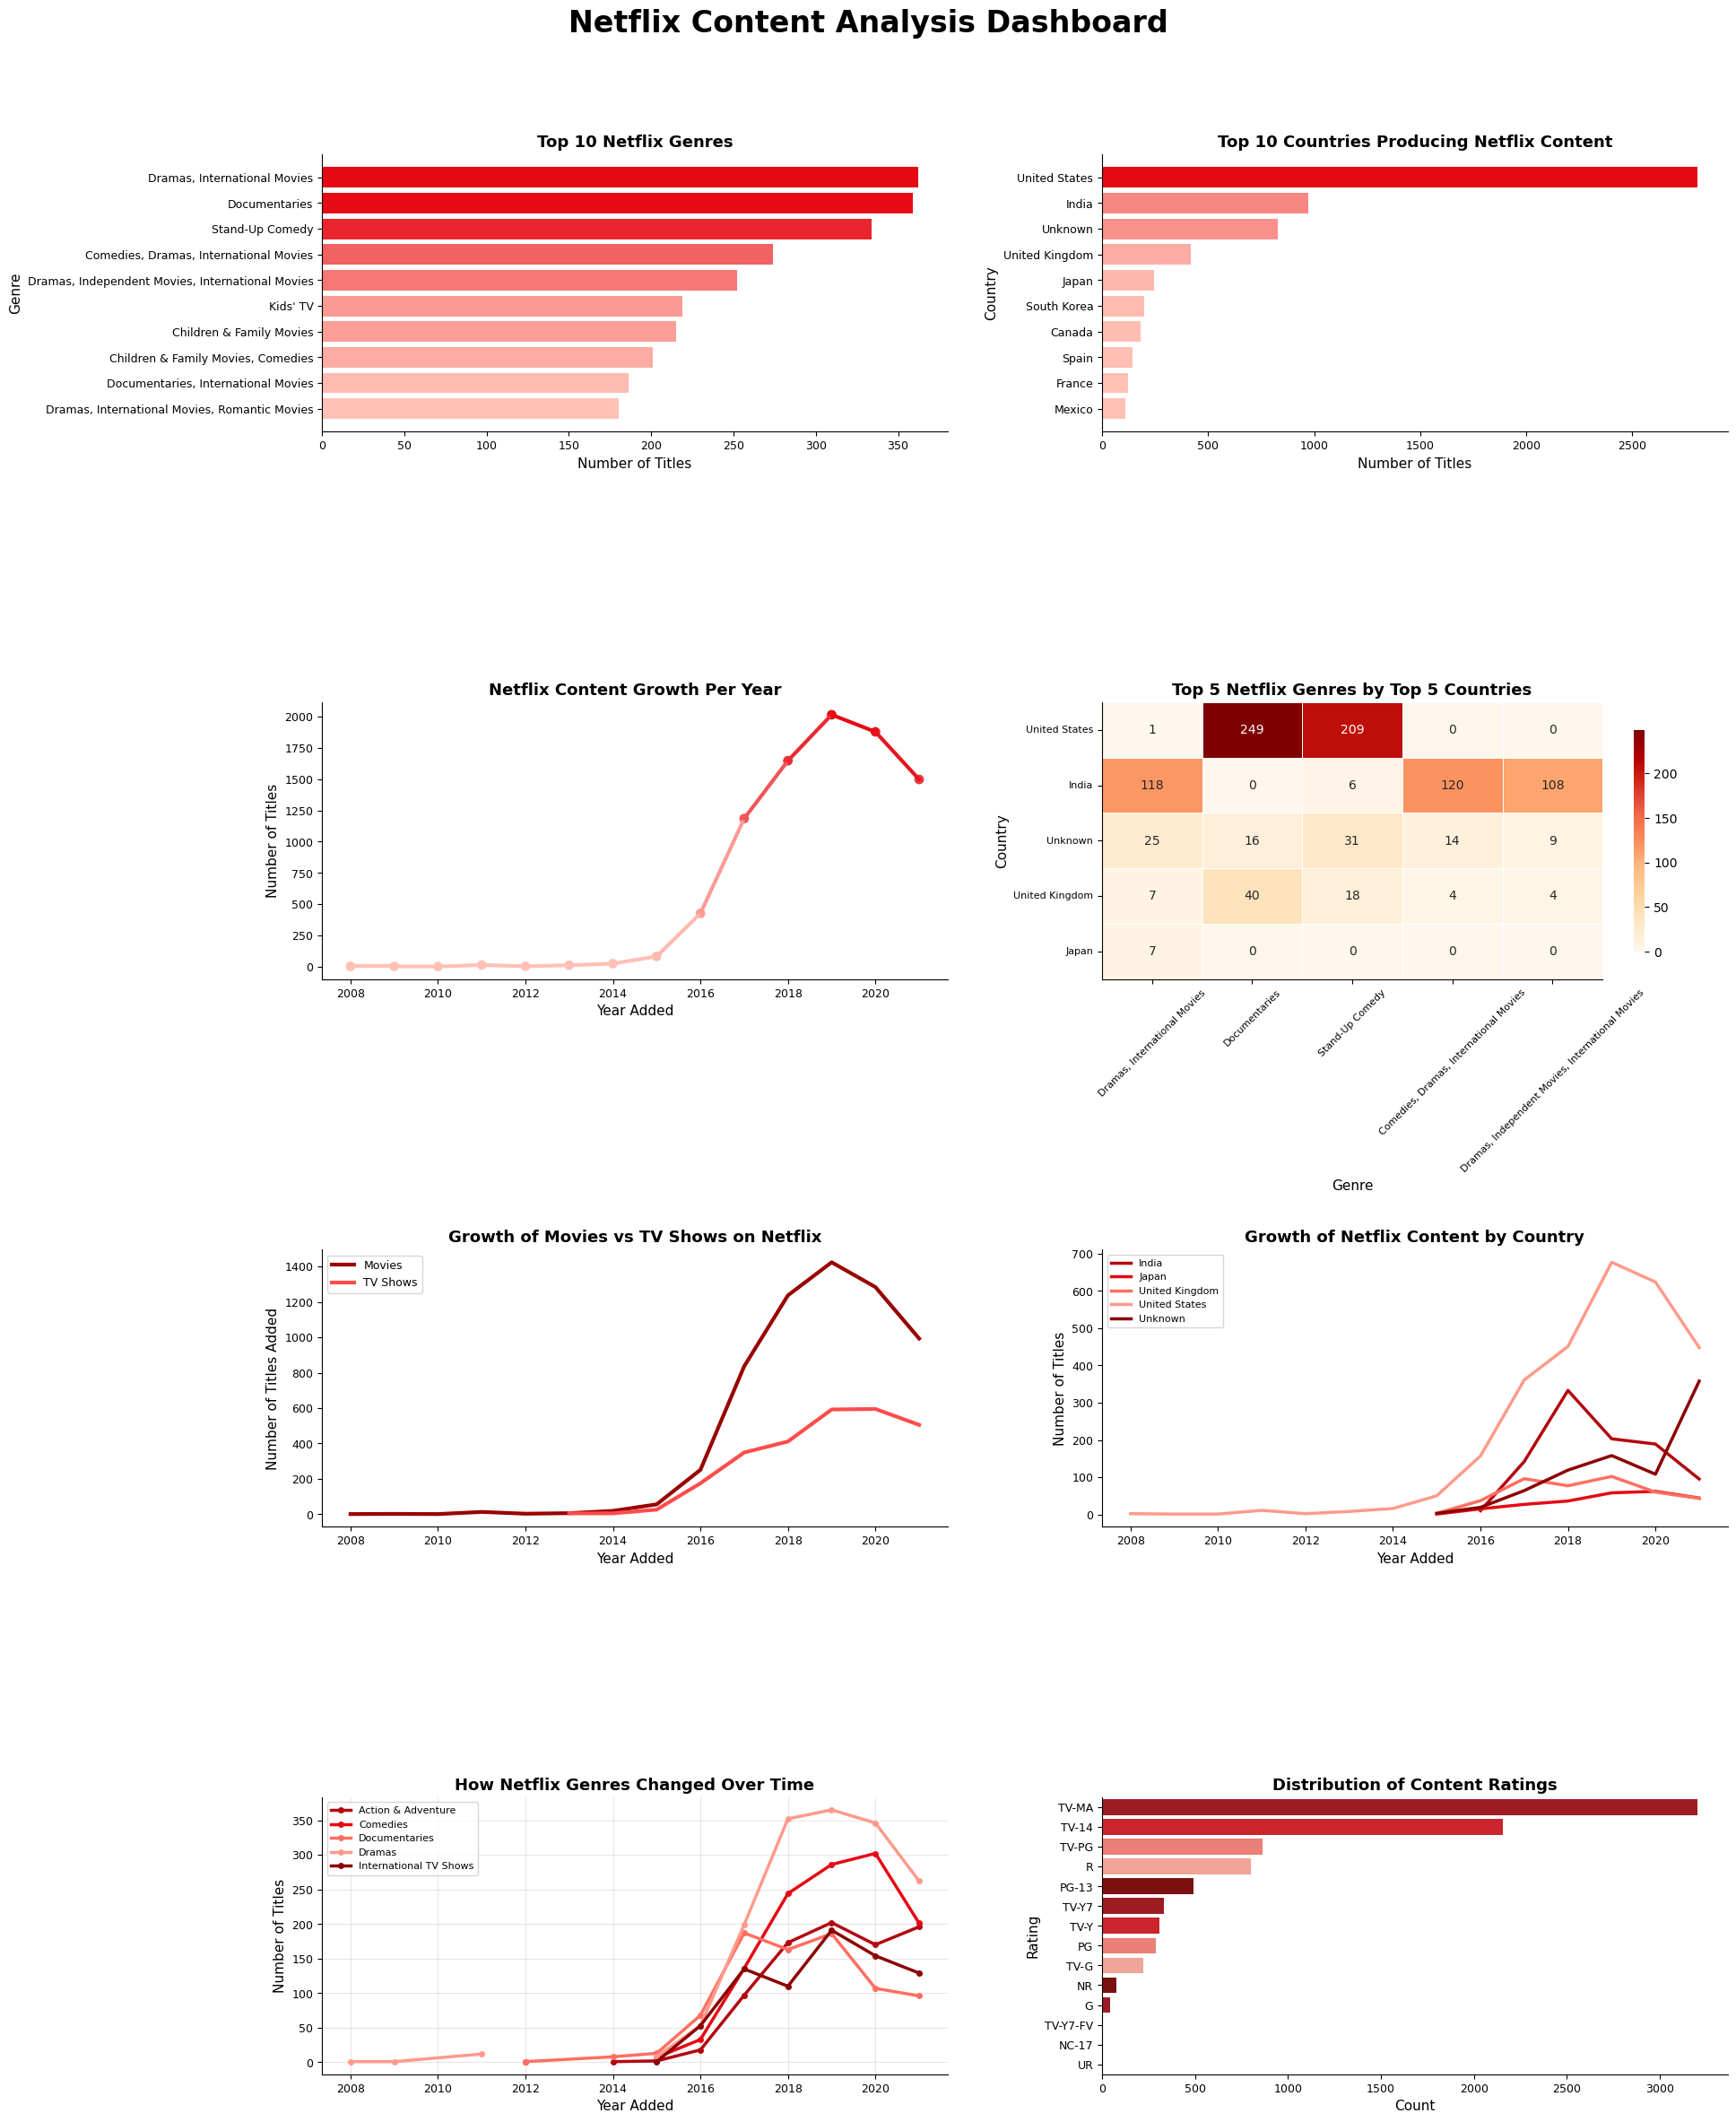

In [18]:
fig, axes = plt.subplots(4, 2, figsize=(20, 24))
fig.suptitle("Netflix Content Analysis Dashboard", fontsize=24, fontweight='bold', y=0.995)


axes[0, 0].barh(top10_values.index, top10_values.values, color=colors_bar)
axes[0, 0].set_title("Top 10 Netflix Genres", fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel("Number of Titles", fontsize=11)
axes[0, 0].set_ylabel("Genre", fontsize=11)
axes[0, 0].invert_yaxis()
axes[0, 0].tick_params(axis='both', labelsize=9)


norm_country = mcolors.Normalize(vmin=titles_per_country.min(), vmax=titles_per_country.max())
colors_country = [cmap(norm_country(v)) for v in titles_per_country.values]

axes[0, 1].barh(titles_per_country.index, titles_per_country.values, color=colors_country)
axes[0, 1].set_title("Top 10 Countries Producing Netflix Content", fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel("Number of Titles", fontsize=11)
axes[0, 1].set_ylabel("Country", fontsize=11)
axes[0, 1].invert_yaxis()
axes[0, 1].tick_params(axis='both', labelsize=9)


for i in range(len(years) - 1):
    axes[1, 0].plot(
        years[i:i+2],
        num_titles[i:i+2],
        color=colors_line[i],
        linewidth=3
    )

axes[1, 0].scatter(
    years,
    num_titles,
    color=[cmap(norm_line(v)) for v in num_titles],
    s=45
)
axes[1, 0].set_title("Netflix Content Growth Per Year", fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel("Year Added", fontsize=11)
axes[1, 0].set_ylabel("Number of Titles", fontsize=11)
axes[1, 0].tick_params(axis='both', labelsize=9)


sns.heatmap(
    top_ct_data,
    annot=True,
    fmt='d',
    cmap="OrRd",
    linewidths=.5,
    ax=axes[1, 1],
    cbar_kws={"shrink": 0.8}
)
axes[1, 1].set_title("Top 5 Netflix Genres by Top 5 Countries", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Genre", fontsize=11)
axes[1, 1].set_ylabel("Country", fontsize=11)
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1, 1].tick_params(axis='y', rotation=0, labelsize=8)


axes[2, 0].plot(
    growth.index, growth['Movie'],
    label='Movies', color='#990000', linewidth=3
)
axes[2, 0].plot(
    growth.index, growth['TV Show'],
    label='TV Shows', color='#FF4C4C', linewidth=3
)
axes[2, 0].set_title("Growth of Movies vs TV Shows on Netflix", fontsize=13, fontweight='bold')
axes[2, 0].set_xlabel("Year Added", fontsize=11)
axes[2, 0].set_ylabel("Number of Titles Added", fontsize=11)
axes[2, 0].legend(fontsize=9, frameon=True)
axes[2, 0].tick_params(axis='both', labelsize=9)


for i, country in enumerate(country_growth.columns):
    axes[2, 1].plot(
        country_growth.index,
        country_growth[country],
        label=country,
        color=CountryColors[i % len(CountryColors)],
        linewidth=2.5
    )

axes[2, 1].set_title("Growth of Netflix Content by Country", fontsize=13, fontweight='bold')
axes[2, 1].set_xlabel("Year Added", fontsize=11)
axes[2, 1].set_ylabel("Number of Titles", fontsize=11)
axes[2, 1].legend(fontsize=8, frameon=True)
axes[2, 1].tick_params(axis='both', labelsize=9)


for i, genre in enumerate(genre_growth.columns):
    axes[3, 0].plot(
        genre_growth.index,
        genre_growth[genre],
        label=genre,
        color=GGcolors[i % len(GGcolors)],
        linewidth=2.5,
        marker='o',
        markersize=4
    )

axes[3, 0].set_title("How Netflix Genres Changed Over Time", fontsize=13, fontweight='bold')
axes[3, 0].set_xlabel("Year Added", fontsize=11)
axes[3, 0].set_ylabel("Number of Titles", fontsize=11)
axes[3, 0].grid(alpha=0.3)
axes[3, 0].legend(fontsize=8, frameon=True)
axes[3, 0].tick_params(axis='both', labelsize=9)

rating_colors = (GGcolors * 10)[:len(order)]

sns.countplot(
    data=df,
    y='rating',
    order=order,
    palette=rating_colors,
    ax=axes[3, 1]
)
axes[3, 1].set_title("Distribution of Content Ratings", fontsize=13, fontweight='bold')
axes[3, 1].set_xlabel("Count", fontsize=11)
axes[3, 1].set_ylabel("Rating", fontsize=11)
axes[3, 1].tick_params(axis='both', labelsize=9)


for ax in axes.flat:
    sns.despine(ax=ax)


plt.tight_layout(rect=[0, 0, 1, 0.985], pad=3.0)
plt.show()

Conclusion
=

This project provided a comprehensive analysis of Netflix’s content landscape, revealing how the platform has evolved in terms of genres, global production, growth trends, and audience targeting. The findings show that Netflix has transitioned from a U.S.-focused service into a globally diversified platform, driven by a strong shift toward original content and international expansion. While dramas and mature-rated content dominate the catalog, emerging markets and diverse genres are playing an increasingly important role in shaping its future. Overall, the analysis highlights Netflix’s strategic balance between maintaining mainstream appeal and adapting to regional preferences, positioning it as a leading global streaming service in an increasingly competitive industry.